# II. Cuspidality analysis: the cuspidal case

In this session, we will analyse the cuspidality of elementary robots using `AlgebraicSolving.jl`.

In [1]:
using Pkg, Plots, AlgebraicSolving
import AlgebraicSolving.change_ringvar, AlgebraicSolving.gens, AlgebraicSolving.factor

### A 3 revolute joint orthogonal robot:
![A 3R robot](../3rrobot-shrink.png)

We start with a robot whose algebraic kinematic map is:
$$
\begin{array}{cccc}
     \mathcal{K} \colon& V &\longrightarrow & \mathbb{R}^3 \\
     &(c_1,c_2, c_3, s_1, s_2, s_3) &\longmapsto
    &\big(z_1(\bm{c},\bm{s}), z_2(\bm{c},\bm{s}),z_3(\bm{c},\bm{s})\big)
 \end{array}
 $$

where
$\left\{\begin{array}{l}
 z_1 = \frac{1}{2}c_1c_2(3c_3 + 4) - \frac{1}{2}s_1(3s_3 + 2) + c_1\\[.5em]
 z_2 = \frac{1}{2}s_1c_2(3c_3 + 4) + \frac{1}{2}c_1(3s_3 + 2) + s_1\\[[.5em]
z_3 = -\frac{1}{2}s_2(3c_3 + 4)
 \end{array}\right.$

### A. System Definition

First, initialize the multivariate polynomial ring over the rationals (`QQ`) for our 6 variables: `c1, c2, c3, s1, s2, s3`.

In [2]:
R, (c1, c2, c3, s1, s2, s3) = polynomial_ring(QQ, [:c1,:c2,:c3,:s1,:s2,:s3])

(Multivariate polynomial ring in 6 variables over QQ, QQMPolyRingElem[c1, c2, c3, s1, s2, s3])

Now, we define our kinematic map $K$ and the ideal $V$ constraining the (co)sines ($c_i^2 + s_i^2 - 1 = 0$).

In [3]:
K = 1//2 * [ c1*c2*(3*c3+4) - s1*(3*s3+2) + c1, s1*c2*(3*c3+4) + c1*(3*s3+2) + s1, -s2*(3*c3+4) ]
V = Ideal([c1^2+s1^2-1, c2^2+s2^2-1, c3^2+s3^2-1])

[K, V]

2-element Vector{Any}:
 QQMPolyRingElem[3//2*c1*c2*c3 + 2*c1*c2 + 1//2*c1 - 3//2*s1*s3 - s1, 3//2*c1*s3 + c1 + 3//2*c2*c3*s1 + 2*c2*s1 + 1//2*s1, -3//2*c3*s2 - 2*s2]
 QQMPolyRingElem[c1^2 + s1^2 - 1, c2^2 + s2^2 - 1, c3^2 + s3^2 - 1]

<details>
<summary><b>► Show Solution</b></summary>

```julia
V = Ideal([ c1^2 + s1^2 - 1, c2^2 + s2^2 - 1, c3^2 + s3^2 - 1 ])
```
</details>

In [4]:
dimension(V), hilbert_degree(V)

(3, 8)

### B. Polar Varieties and Critical Points

Use the `computepolar` function to extract the critical points with respect to the map $K$.

In [5]:
# Compute the polar variety
critK = computepolar(1:3, V, phi=K)

4-element Vector{QQMPolyRingElem}:
 c1^2 + s1^2 - 1
 c2^2 + s2^2 - 1
 c3^2 + s3^2 - 1
 27*c1^2*c2^3*c3^2*s3 + 72*c1^2*c2^3*c3*s3 + 48*c1^2*c2^3*s3 + 9*c1^2*c2^2*c3*s3 + 12*c1^2*c2^2*s3 + 27*c1^2*c2*c3^2*s2^2*s3 - 27*c1^2*c2*c3^2*s3 - 18*c1^2*c2*c3^2 + 72*c1^2*c2*c3*s2^2*s3 - 36*c1^2*c2*c3*s3 - 24*c1^2*c2*c3 + 48*c1^2*c2*s2^2*s3 + 9*c1^2*c3*s2^2*s3 + 12*c1^2*s2^2*s3 + 27*c2^3*c3^2*s1^2*s3 + 72*c2^3*c3*s1^2*s3 + 48*c2^3*s1^2*s3 + 9*c2^2*c3*s1^2*s3 + 12*c2^2*s1^2*s3 + 27*c2*c3^2*s1^2*s2^2*s3 - 27*c2*c3^2*s1^2*s3 - 18*c2*c3^2*s1^2 + 72*c2*c3*s1^2*s2^2*s3 - 36*c2*c3*s1^2*s3 - 24*c2*c3*s1^2 + 48*c2*s1^2*s2^2*s3 + 9*c3*s1^2*s2^2*s3 + 12*s1^2*s2^2*s3

<details>
<summary><b>► Show Solution</b></summary>

```julia
critK = computepolar(1:3, V, phi=K)
```
</details>

In [6]:
dimension(Ideal(critK)), hilbert_degree(Ideal(critK))

(2, 24)

Factoring defining polynomials can often lead to (substantial) simplifications

In [7]:
fact = AlgebraicSolving.factor(critK[end])
L_fact = getindex.(collect(fact), 1)

3-element Vector{QQMPolyRingElem}:
 c1^2 + s1^2
 3*c3 + 4
 3*c2^3*c3*s3 + 4*c2^3*s3 + c2^2*s3 + 3*c2*c3*s2^2*s3 - 3*c2*c3*s3 - 2*c2*c3 + 4*c2*s2^2*s3 + s2^2*s3

Pick the right factor(s)

In [8]:
critK[end] = L_fact[end]

3*c2^3*c3*s3 + 4*c2^3*s3 + c2^2*s3 + 3*c2*c3*s2^2*s3 - 3*c2*c3*s3 - 2*c2*c3 + 4*c2*s2^2*s3 + s2^2*s3

<details>
<summary><b>► Show Solution</b></summary>

```julia
critK[end] = L_fact[end]
```
</details>

### C. The Direct Approach

Let's introduce 3 new variables ($z_1, z_2, z_3$) and attempt standard elimination.

We must first inject polynomials in the extended ring.

In [9]:
K_z = [ change_ringvar(f, [:c1,:c2,:c3,:s1,:s2,:s3,:z1,:z2,:z3]) for f in K ]
critK_z = [ change_ringvar(f, [:c1,:c2,:c3,:s1,:s2,:s3,:z1,:z2,:z3]) for f in critK ]

4-element Vector{QQMPolyRingElem}:
 c1^2 + s1^2 - 1
 c2^2 + s2^2 - 1
 c3^2 + s3^2 - 1
 3*c2^3*c3*s3 + 4*c2^3*s3 + c2^2*s3 + 3*c2*c3*s2^2*s3 - 3*c2*c3*s3 - 2*c2*c3 + 4*c2*s2^2*s3 + s2^2*s3

We get the new variables

In [10]:
Z = AlgebraicSolving.gens(parent(K_z[1]))[end-2:end]

3-element Vector{QQMPolyRingElem}:
 z1
 z2
 z3

Set `Z[1], Z[2], Z[3]` to be the image of $K$ on $V$ by adding new equations encoding it

In [11]:
new_eqs = [Z[1] - K_z[1], Z[2] - K_z[2], Z[3] - K_z[3]]
KcritK = Ideal(vcat(critK_z, new_eqs))

QQMPolyRingElem[c1^2 + s1^2 - 1, c2^2 + s2^2 - 1, c3^2 + s3^2 - 1, 3*c2^3*c3*s3 + 4*c2^3*s3 + c2^2*s3 + 3*c2*c3*s2^2*s3 - 3*c2*c3*s3 - 2*c2*c3 + 4*c2*s2^2*s3 + s2^2*s3, -3//2*c1*c2*c3 - 2*c1*c2 - 1//2*c1 + 3//2*s1*s3 + s1 + z1, -3//2*c1*s3 - c1 - 3//2*c2*c3*s1 - 2*c2*s1 - 1//2*s1 + z2, 3//2*c3*s2 + 2*s2 + z3]

<details>
<summary><b>► Show Solution</b></summary>

```julia
[Z[1] - K_z[1], Z[2] - K_z[2], Z[3] - K_z[3]]
```
</details>

We now project on the $z_i$ by elimination and inject in the polynomial ring only in the $z_i$

In [12]:
# Eliminate the variable
G = eliminate(KcritK, 6)
svalK = change_ringvar(G)

1-element Vector{QQMPolyRingElem}:
 16*z1^16 + 128*z1^14*z2^2 + 128*z1^14*z3^2 - 448*z1^14 + 448*z1^12*z2^4 + 896*z1^12*z2^2*z3^2 - 3136*z1^12*z2^2 + 448*z1^12*z3^4 - 3456*z1^12*z3^2 + 3048*z1^12 + 896*z1^10*z2^6 + 2688*z1^10*z2^4*z3^2 - 9408*z1^10*z2^4 + 2688*z1^10*z2^2*z3^4 - 20736*z1^10*z2^2*z3^2 + 18288*z1^10*z2^2 + 896*z1^10*z3^6 - 11328*z1^10*z3^4 + 23984*z1^10*z3^2 - 4392*z1^10 + 1120*z1^8*z2^8 + 4480*z1^8*z2^6*z3^2 - 15680*z1^8*z2^6 + 6720*z1^8*z2^4*z3^4 - 51840*z1^8*z2^4*z3^2 + 45720*z1^8*z2^4 + 4480*z1^8*z2^2*z3^6 - 56640*z1^8*z2^2*z3^4 + 119920*z1^8*z2^2*z3^2 - 21960*z1^8*z2^2 + 1120*z1^8*z3^8 - 20480*z1^8*z3^6 + 79544*z1^8*z3^4 + 29072*z1^8*z3^2 + 43153*z1^8 + 896*z1^6*z2^10 + 4480*z1^6*z2^8*z3^2 - 15680*z1^6*z2^8 + 8960*z1^6*z2^6*z3^4 - 69120*z1^6*z2^6*z3^2 + 60960*z1^6*z2^6 + 8960*z1^6*z2^4*z3^6 - 113280*z1^6*z2^4*z3^4 + 239840*z1^6*z2^4*z3^2 - 43920*z1^6*z2^4 + 4480*z1^6*z2^2*z3^8 - 81920*z1^6*z2^2*z3^6 + 318176*z1^6*z2^2*z3^4 + 116288*z1^6*z2^2*z3^2 + 172612*z1^6*z2^2 +

We now attempt to compute one point in each connected component of $\mathbb{R}^3 \setminus \mathrm{sval}(K)$.

In [13]:
Q_sval = points_per_components(
QQMPolyRingElem[],
QQMPolyRingElem[],
svalK,
info_level=1)

Bivariate sample points        20 / 20 (3.953 s) (done)
Trivariate sample points        200 / 200 (7.798 s) (done)


768-element Vector{Vector{Vector{QQFieldElem}}}:
 [[-8, -8], [0, 0], [0, 0]]
 [[-436277176508528958886469278725//79228162514264337593543950336, -436277176508528958886469278725//79228162514264337593543950336], [-6, -6], [0, 0]]
 [[-436277176508528958886469278725//79228162514264337593543950336, -436277176508528958886469278725//79228162514264337593543950336], [0, 0], [0, 0]]
 [[-436277176508528958886469278725//79228162514264337593543950336, -436277176508528958886469278725//79228162514264337593543950336], [6, 6], [0, 0]]
 [[-74230430624831842895631640321//19807040628566084398385987584, -74230430624831842895631640321//19807040628566084398385987584], [-7, -7], [0, 0]]
 [[-74230430624831842895631640321//19807040628566084398385987584, -74230430624831842895631640321//19807040628566084398385987584], [-150102968195875755206324065083//39614081257132168796771975168, -150102968195875755206324065083//39614081257132168796771975168], [0, 0]]
 [[-74230430624831842895631640321//19807040628566084398385987

<details>
<summary><b>► Show Solution</b></summary>

```julia
Q_sval = points_per_components(
QQMPolyRingElem[],
QQMPolyRingElem[],
svalK,
info_level=1)
```
</details>

Axial symmetry w.r.t. $\theta_1$

In [14]:
# Configuration space
groebner_basis(Ideal(critK))

7-element Vector{QQMPolyRingElem}:
 c3^2 + s3^2 - 1
 2*c2*c3 - 4*c2*s3 - s3
 c2^2 + s2^2 - 1
 c1^2 + s1^2 - 1
 10*c2*s3^2 - 2*c2 + c3*s3 + 2*s3^2
 c2*s3 + 2*c3*s2^2 - 2*c3 - 4*s2^2*s3 + 4*s3
 -8*c2 + 4*c3*s3 + 100*s2^2*s3^2 - 20*s2^2 - 97*s3^2 + 20

In [15]:
# Workspace (cylindrical coordinates)
A, (rho, cp, sp, z) = polynomial_ring(QQ, [:rho,:cp,:sp,:z])
groebner_basis(Ideal([cp^2+sp^2-1, svalK[1](rho*cp, rho*sp, z)]))

2-element Vector{QQMPolyRingElem}:
 cp^2 + sp^2 - 1
 16*rho^16 + 128*rho^14*z^2 - 448*rho^14 + 448*rho^12*z^4 - 3456*rho^12*z^2 + 3048*rho^12 + 896*rho^10*z^6 - 11328*rho^10*z^4 + 23984*rho^10*z^2 - 4392*rho^10 + 1120*rho^8*z^8 - 20480*rho^8*z^6 + 79544*rho^8*z^4 + 29072*rho^8*z^2 + 43153*rho^8 + 896*rho^6*z^10 - 22080*rho^6*z^8 + 139296*rho^6*z^6 - 19056*rho^6*z^4 - 706764*rho^6*z^2 - 42822*rho^6 + 448*rho^4*z^12 - 14208*rho^4*z^10 + 134744*rho^4*z^8 - 263808*rho^4*z^6 - 893650*rho^4*z^4 + 747424*rho^4*z^2 + 135627*rho^4 + 128*rho^2*z^14 - 5056*rho^2*z^12 + 68144*rho^2*z^10 - 332200*rho^2*z^8 + 320196*rho^2*z^6 - 1018070*rho^2*z^4 + 788432*rho^2*z^2 - 241454*rho^2 + 16*z^16 - 768*z^14 + 14088*z^12 - 120912*z^10 + 469961*z^8 - 658740*z^6 + 443910*z^4 - 150900*z^2 + 21025

### D. A geometric simplification

By intelligently changing our coordinate system (using $\rho$ and $z$), we can bypass the previous explosion in complexity.

In [34]:
R_polar, (c2,c3,s2,s3,rho,z) = polynomial_ring(QQ, [:c2,:c3,:s2,:s3,:rho,:z])
K_polar, critK_polar = [ [ f(1,c2,c3,0,s2,s3) for f in E if !iszero(f(1,c2,c3,0,s2,s3))] for E in [K, critK] ]

# We now project on (rho, z)
KcritK_polar = Ideal(vcat([z - K_polar[end], rho^2 - K_polar[1]^2 - K_polar[2]^2], critK_polar))

# Eliminate the variables
G = eliminate(KcritK_polar, 4)
svalK_polar = change_ringvar(G, [:rho,:z])
new_rho = change_ringvar(rho, [:rho,:z])

Wsval_polar = points_per_components(QQMPolyRingElem[], [new_rho], svalK_polar, info_level=2)

Bivariate sample points        20 / 20 (0.417 s) (done)


50-element Vector{Vector{Vector{QQFieldElem}}}:
 [[5997089357897624304616158157//39614081257132168796771975168, 5997089357897624304616158157//39614081257132168796771975168], [-5, -5]]
 [[5997089357897624304616158157//39614081257132168796771975168, 5997089357897624304616158157//39614081257132168796771975168], [-484676482078992006877063126619//158456325028528675187087900672, -484676482078992006877063126619//158456325028528675187087900672]]
 [[5997089357897624304616158157//39614081257132168796771975168, 5997089357897624304616158157//39614081257132168796771975168], [-152192124121062491499887316781//79228162514264337593543950336, -152192124121062491499887316781//79228162514264337593543950336]]
 [[5997089357897624304616158157//39614081257132168796771975168, 5997089357897624304616158157//39614081257132168796771975168], [-848726453313015620259//1180591620717411303424, -848726453313015620259//1180591620717411303424]]
 [[5997089357897624304616158157//39614081257132168796771975168, 59970893578976

### E. Roadmap computation
We now need to compute a roadmap for the semi-algebraic set defined by $V \setminus \mathrm{crit}(\mathcal{K}, V)$ i.e. by
$$
c_i^2 + s_i^2 =1 \text{\quad and \quad}
\texttt{critK[end]} \neq 0
$$

To reduce to algebraic sets, we use here for simplicity the Rabinowitsch's trick to convert disequalities into equalities.
We represent the semi-algebraic set as a projection by introducing a new variable $u$:
$$
\{ f \neq 0 \}  \longrightarrow \{u\cdot f = 1\}.
$$

NB: In practice, this leads to complexity explosion as complexities are intrinsically exponential in a polynomial of number of variables.

In [35]:
R_rab,(u,c2,c3,s2,s3) = polynomial_ring(QQ, [:u,:c2,:c3,:s2,:s3])
critK_rab = [ f(c2,c3,s2,s3,0,0) for f in critK_polar ]
K1_rab = [ f(c2,c3,s2,s3,0,0) for f in K_polar ]

3-element Vector{QQMPolyRingElem}:
 3//2*c2*c3 + 2*c2 + 1//2
 3//2*s3 + 1
 -3//2*c3*s2 - 2*s2

In [36]:
# Lifting of the sa set as an algebraic set
Vmcrit_rab = vcat(critK_rab[1:end-1], 1 - u*critK_rab[end])

3-element Vector{QQMPolyRingElem}:
 c2^2 + s2^2 - 1
 c3^2 + s3^2 - 1
 -3*u*c2^3*c3*s3 - 4*u*c2^3*s3 - u*c2^2*s3 - 3*u*c2*c3*s2^2*s3 + 3*u*c2*c3*s3 + 2*u*c2*c3 - 4*u*c2*s2^2*s3 - u*s2^2*s3 + 1

We recompute the candidate points

In [37]:
# Fiber equations
Wsval_rab = [ vcat(Vmcrit_rab, sum(rfib)//2 - K1_rab[1]^2 - K1_rab[2]^2, sum(zfib)//2 - K1_rab[end]) for (rfib, zfib) in Wsval_polar ]
# Real root isolation
#Wcusp_isolated_rab = filter(!isempty, [ real_solutions(Ideal(w), interval=true)  for w in Wcusp_rab ])

50-element Vector{Vector{QQMPolyRingElem}}:
 [c2^2 + s2^2 - 1, c3^2 + s3^2 - 1, -3*u*c2^3*c3*s3 - 4*u*c2^3*s3 - u*c2^2*s3 - 3*u*c2*c3*s2^2*s3 + 3*u*c2*c3*s3 + 2*u*c2*c3 - 4*u*c2*s2^2*s3 - u*s2^2*s3 + 1, -9//4*c2^2*c3^2 - 6*c2^2*c3 - 4*c2^2 - 3//2*c2*c3 - 2*c2 - 9//4*s3^2 - 3*s3 - 43520512213517586691348810803//39614081257132168796771975168, 3//2*c3*s2 + 2*s2 - 5]
 [c2^2 + s2^2 - 1, c3^2 + s3^2 - 1, -3*u*c2^3*c3*s3 - 4*u*c2^3*s3 - u*c2^2*s3 - 3*u*c2*c3*s2^2*s3 + 3*u*c2*c3*s3 + 2*u*c2*c3 - 4*u*c2*s2^2*s3 - u*s2^2*s3 + 1, -9//4*c2^2*c3^2 - 6*c2^2*c3 - 4*c2^2 - 3//2*c2*c3 - 2*c2 - 9//4*s3^2 - 3*s3 - 43520512213517586691348810803//39614081257132168796771975168, 3//2*c3*s2 + 2*s2 - 484676482078992006877063126619//158456325028528675187087900672]
 [c2^2 + s2^2 - 1, c3^2 + s3^2 - 1, -3*u*c2^3*c3*s3 - 4*u*c2^3*s3 - u*c2^2*s3 - 3*u*c2*c3*s2^2*s3 + 3*u*c2*c3*s3 + 2*u*c2*c3 - 4*u*c2*s2^2*s3 - u*s2^2*s3 + 1, -9//4*c2^2*c3^2 - 6*c2^2*c3 - 4*c2^2 - 3//2*c2*c3 - 2*c2 - 9//4*s3^2 - 3*s3 - 43520512213517

In [38]:
RM_rab = roadmap(Ideal(Vmcrit_rab), Ideal(Wsval_rab[end]), info_level=1)

Try linear forms QQMPolyRingElem[u, c2]
Compute L1-critical points: K1
Compute L_e2-polar variety: W
Compute W-critical points with <<vertical>> tangent: K1W


Vector{Tuple{QQMPolyRingElem, QQFieldElem}}[[], [(u, -1907713080//6099380351)], [(u, -1687750753//8930737535)], [(u, 0)], [(u, 393277344//2081028097)], [(u, 1907713080//6099380351)]]

In [39]:
hilbert_degree.(all_eqs(RM_rab))

6-element Vector{Int64}:
 16
  8
  8
  0
  8
  8

In [40]:
GRM_rab = curve_arrangement_graph(all_eqs(RM_rab), Ideal(Wsval_rab[end]), generic=15, v=3)

Compute graph of curve number 1/6...
Compute parametrization of critical pts...
Compute subresultant sequence
  0.424609 seconds (381.55 k allocations: 212.883 MiB, 9.71% gc time)
Compute apparent singularities
Compute gcd decomposition
  4.019656 seconds (5.91 M allocations: 488.328 MiB, 3.10% gc time, 88.33% compilation time)
Computing insulating critical boxes
Refining index 0 -> prec = 300
Refining index 1 -> prec = 300
  1.158096 seconds (2.47 M allocations: 134.105 MiB, 89.66% compilation time: <1% of which was recompilation)
Compute intersections with critical boxes..
i=0 (38/38)
i=-5 (4/4)
i=2 (4/4)
i=-1 (4/4)
i=-3 (8/8)

i=-4 (8/8)
i=-6 (4/4)
i=1 (12/12)
 25.181430 seconds (9.07 M allocations: 3.509 GiB, 2.25% gc time, 1.30% compilation time)
Compute graph of curve number 2/6...
Compute parametrization of critical pts...
Compute subresultant sequence
  0.057807 seconds (35.64 k allocations: 41.296 MiB)
Compute apparent singularities
Compute gcd decomposition
  0.062910 seconds

AlgebraicSolving.CurveGraph{Float64}([(-2.5488220139254754, -20.56960006042308), (10.992289324781686, -20.56960006042308), (54.05002197696403, -20.56960006042308), (63.14708322351411, -20.56960006042308), (-23.799759812806546, -18.190178955488157), (-19.95975449153439, -18.190178955488157), (-5.913752863714177, -18.190178955488157), (10.935973892332935, -18.190178955488157), (50.47307640069926, -18.190178955488157), (59.59216965979074, -18.190178955488157)  …  (22.038313505354672, 12.433783776494076), (-8.458359910763372, 11.895653508943022), (-7.692201661407331, 11.895653508943022), (19.58907402620994, 11.895653508943022), (21.497151450238235, 15.503224795981636), (22.49740089786788, 15.503224795981636), (-7.519112445287458, 12.971914044045132), (20.167587808012218, 12.971914044045132), (22.16808670327151, 12.971914044045132), (22.826715092464248, 18.034535547918143)], [(11, 5), (11, 6), (1, 12), (12, 7), (2, 13), (13, 8), (3, 14), (14, 9), (4, 15), (15, 10)  …  (1958, 1589), (1589, 1

In [41]:
group_by_component(GRM_rab)

2-element Vector{Dict{Int64, Vector{Int64}}}:
 Dict(-1 => [380, 790])
 Dict(-1 => [177, 904])

In [42]:
number_of_connected_components(GRM_rab)

2

Bonus: vizualization

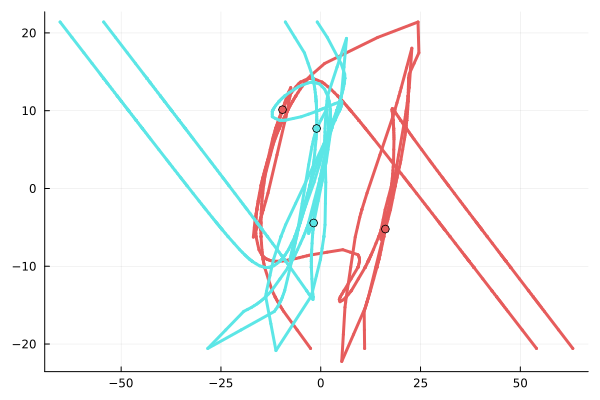

In [43]:
function plot_graph(G)
  P = build_graph_data(G)
  plot(legend=false)
  E = P.edge_group
  plot!(E.edges, color=E.color, width = E.width)
  [scatter!(V.vertices, color=V.color, marker = V.marker) for V in P.point_groups]
  plot!()
  #gui()
end

function plot_graphs(CG)
  CP = build_graph_data(CG, vert=false)
  plot(legend=false)
  for P in CP
      E = P.edge_group
      plot!(E.edges, color=E.color, width = E.width)
      [ scatter!(V.vertices, color=V.color, marker = V.marker) for V in P.point_groups ]
  end
  plot!()
  #gui()
end
plot_graphs(connected_components(GRM_rab))